## 언어모델 사전과제_안가은

### 1. NLP와 언어모델

#### (1) NLP
* 자연어를 컴퓨터가 이해할 수 있는 숫자로 변환하는 기술
* 자연어 특징 -> NLP가 해야 할 일
    * 이산적 데이터다 -> 연속 벡터로 변환하는 과정 필요
    * 순차적 데이터다 -> 데이터 위치 정보 유지하며 처리할 수 있는 모델 구조 필요 (RNN, Transformer)
    * 중의성과 모호성이 있다 -> 문맥을 파악해야함
    * 희소성이 있다(단어 조합 무한하나, 데이터에 나타나는 조합은 일부) -> 일반화 능력 필요
    * 가변성이 있고 진화한다 -> 고정 규칙이 아닌 패턴 학습 능력이 필요함

#### (2). 언어모델
* 언어 모델: 단어 시퀀스(문장)에 확률을 할당하여, 가장 자연스러운 단어 시퀀스를 찾아내는 모델. 이전단어로부터 다음 단어를 예측하도록 훈련시키는 것.
  + 통계 기반 언어모델
  + 신경망 기반 언어모델

### 2. SLM(Statistic Language Model); 통계적 언어모델
* SLM: 분포가설(비슷한 문맥에 함께 나타나는 단어들은 비슷한 의미를 가짐)에 근거한 모델.
* 분포가설의 기본 개념
  + 조건부 확률; ex. "나는 버스를" -> "탔다" 올 확률      
  + 카운트 기반: 이전 단어 시퀀스의 등장 빈도를 통해 다음 단어의 확률 계산
      
    -> 한계: 희소문제: 이전에 경험한 적 있는 조합에 대해서만 잘 예측할 수 있음.         
    -> 새로운 문장 조합에 적용할 수 있는 모델 필요

* N-gram: 희소문제 완화를 위해 단어의 범위를 n개로 정해놓고 참고함       
   -> 카운트할 수 있는 가능성 높이기
  + 정의: 연속된 n개의 단어 묶음(시퀀스). 문장을 n개로 잘라 토큰화함
  + 확률 계산: 다음 단어 예측시 N-1개의 단어만 참고함. (예측 하고자 하는 단어까지 합하여 N개를 보는 것이기 때문)      
  + 한계
  1. 여전히 희소문제 존재
    - 데이터 부족
    - n을 선택하는 것의 문제 (n크게 잡으면 정확도 높아지지만 희소문제 생김 / n 작게 잡으면 희소문제는 줄어들지만 정확도 떨어짐)
  2. 문맥 파악의 한계: n-1개의 단어 앞에 있는 단어는 고려하지 못함.       

* Perplexity(PPL): 언어모델이 특정 문장을 얼마나 **혼란스러워 하는지**를 나타내는 수치. 헷갈리는 정도를 의미한다      
-> 낮을수록 좋음       
-> 신경망 기반 언어 모델은 단어, 문맥 간 관계를 학습하여 일반화 하는 능력 뛰어남

### 3. 신경망 언어 모델 (NLM)
* 임베딩을 함: 모든 단어를 거대한 다차원 지도 위의 한 점으로 보냄 -> 유사 벡터를 인지할 수 있어서, 새로운 문장을 봐도 유사 벡터 기반 문맥 추론이 가능
* 일반화 능력 상승

### 4. 딥러닝 기반 언어모델


#### (1) Transformer
* 인코더와 디코더 층을 여러 겹 쌓아 신경망을 깊게 만드는 것을 가능하게 함
* 언어 모델의 표현력이 높아져 현재의 딥러닝 기반 언어모델을 만들 수 있게 됨

          
#### (2) BERT(Biderectional Encoder Representations from Transformers)       
: 텍스트 앞 뒤 문맥을 동시에 고려하여, 입력값을 벡터로 바꿔주는 딥러닝 모델. 인코더 기반이다
* 특징
  + 양방향: 문장 읽을때 앞뒤 동시에 참조
  + 트랜스포머의 인코더부분 기반임
  + 사전학습 + 파인튜닝: 큰 데이터로 먼저 일반적인 언어 능력 배우고, 나중에 과제에 맞게 살짝 조정 -> MLM(Masked Language Model)과 NSP(Next Sentence Prediction)통해 사전 학습

* BERT의 학습
    + 트랜스포머의 인코더를 여러 개 쌓아올린 구조

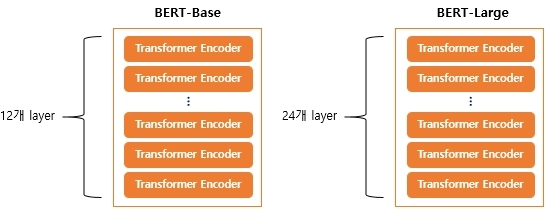

>  BERT의 구조

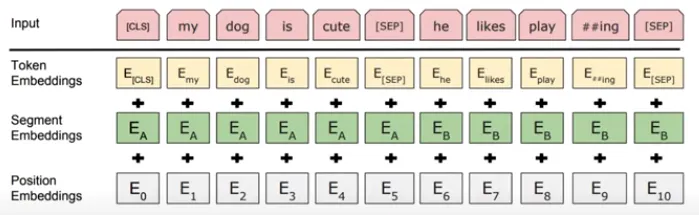

> * BERT의 학습 처리 과정
> * input -> Embedding -> 트랜스포머 인코더(12 or 24) -> Output
> * Embedding: 입력 단어들을 숫자 벡터로 바꿈. 세 가지 임베딩 합쳐서 사용함
>   + Token Embedding: 단어 자체의 의미
>   + Segment Embedding: 두 개 이상의 문장이 들어왔을때 어떤 문장인지 구분
>   + Position Embedding: 단어가 문장에서 몇 번째인지 위치 정보 포함
> * -> 세 개의 정보 더해서 하나의 입력 벡터 생성함

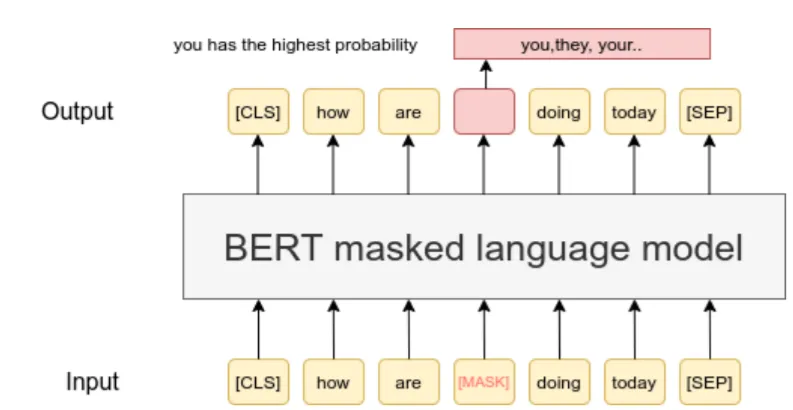

> * 사전학습(1): Masked Language Model (MLM)
> * 빈 칸 채우기 방식의 학습
> * 사전 훈련 위해 들어가는 input 텍스트의 15%정도를 [ 랜덤 마스킹 후 빈칸 뚫기, 랜덤 단어 바꾸기, 그대로 유지하기 ] 섞어 사용

> * 사전학습(2): NSP(Next Sentence Prediction)
> * 두 문장이 실제로 이어지는 문장인지 아닌지 맞히는 학습
> * 두 문장이 이어지는 논리 흐름 학습 가능

* Bert 이후의 모델
  + RoBerTa: 마스킹 패턴을 동적으로 변경해 다양한 패턴 학습하는 등 사전 훈련 프로세스 개선
  + ALBERT: BERT의 경량화 버전. 레이어 간 파라미터 공유, 임베딩 행렬 더 작게 분해

#### (3) GPT(Generative Pre-trained Transformer)

* 트랜스포머의 디코더 기반
* 지금까지 단어 바탕으로 다음 단어 예측
* gpt-3부터는 few-shot learning 도입됨: 몇 개의 예시를 보고 task 수행

#### (4) LLM (Large Language Model)
: 거대 언어 모델로, 방대한 양의 데이터를 학습하여 자연어 및 기타 유형의 콘텐츠를 이해하고 생성하여 광범위한 작업을 수행할 수 있는 기초 모델의 범주 (GPT, Gemini 등) 
* 작동 방식
  1. 대규모 학습: 인터넷 웹페이지, 책, 기사 등을 학습하고 언어의 패턴을 스스로 학습함
  2. 예측 및 생성: 학습이 완료된 LLM이 프롬프트를 받으면, 학습 패턴을 기반으로 다음에 올 가장 확률 높은 단어를 순서대로 예측하며 응답을 생성한다.
   - GPT 방식 사용 (디코더 기반). 얘가 문장 생성에 더 유리함


* LLM의 한계
  + Hallucinaiton(환각): 사실이 아닌 내용을 그럴듯하게 만들어내는 현상
  + 업데이트 비용: 파라미터 수가 많아서 새 정보 반영시 계산량 많음

#### (5) RAG(Retrieval Augmented Generation)
: 외부에서 최신 정보 가져와 찾고, 이를 LLM에 넣어 최종 답변을 생성하는 하나의 파이프라인

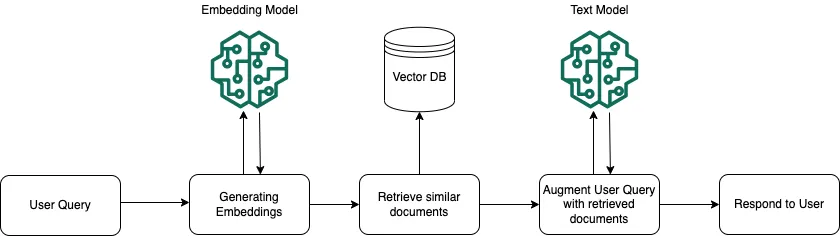

> * RAG의 구조
> 1. 질의 인코더: 사용자의 질문 벡터로 인코딩
> 2. 지식 검색기: 인코딩된 질문을 바탕으로 외부 지식 베이스에서 관련 정보 검색
> 3. 지식 증강 생성기: 검색된 지식을 활용해 질문에 대한 답변 생성하는 모델.

* RAG의 장점
   + 최신 정보 반영 가능
   + 할루시네이션 문제 감소
   + 정보 정확성 증가

* CAG(Credibility-Aware Generation)
  + RAG의 한계 보완위한 프레임 워크
  + 문서의 신뢰도를 판단해 활용할 수 있도록 훈련시키는 기법
  + 구조: 질문 입력 -> 정보 검색 -> 각 정보 신뢰도 평가 -> 높은 신뢰도 정보 우선 사용 -> 최종 답변 생성

#### (6) LangChain
: LLM + RAG 모델 구현 파이프라인을 쉽게 구성하게 하는 프레임 워크.
* LLM을 기반으로 앱 제작 시 필요 구성요소를 쉽게 연결할 수 있음
* 특징
  1. 추상화: LLM서비스 만들 때 필요한 각종 작업을 간결하게 표현해주고 간소화 해줌
  2. 표준화: 다양한 원본 데이터(엑셀, 크롬, 워드 ..)-> 표준화된 형태로 표현 / 다양한 AI모델(GPT, Claude, .. )-> 하나의 형식으로 통일
  3. 체이닝: 자주 활용하는 주요 컴포넌트를 쉽게 연결해서 LLM 서비스의 로직을 쉽게 파악 (input -> 컴포넌트 -> output)

* LangGraph: 비선형적인 작업 형태로 기존 LangChain의 고정된 작업 순서에서 벗어나 순환, 반복 로직을 만들 수 있게 하여 결과 보강 가능

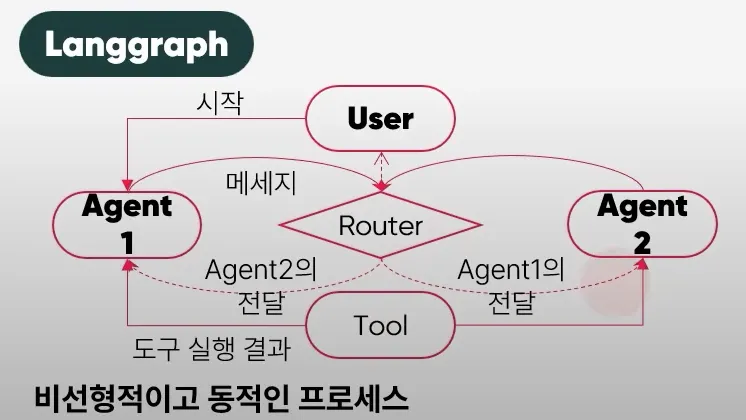

> * 노드: 특정 작업을 수행하는 단위. 랭체인의 컴포넌트 그대로 사용 가능
> * 엣지: 노드와 노드 연결하는 선. 조건부 엣지 활용가능

* LangSmith: LLM기반 애플리케이션을 위한 통합 개발 및 운영 플랫폼
  + 핵심 기능
    1. 디버깅 및 추적: LLM의 모든 실행 과정 단계별로 시각화
    2. 테스트 및 평가: 준비된 질문과 정답 데이터셋 만들어 성능 자동 평가
    3. 모니터링: 사용자들 모니터링
    4. 프롬프트 허브: 다양한 프롬프트 저장, 버전관리, 테스트 할 수 있는 공간 제공

* 외부 API 활용: LLM내부 지식으로 해결할 수 없는 질문에 대해 외부 API연동 가능.

### 5. sLM(small Language Model)
: 소규모 언어 모델. 자연어 콘텐츠를 처리, 이해, 생성할 수 있는 AI모델로 LLM보다 규모와 범위가 작다. (경량화, 빠른 학습 최적화, 적은 비용)

(1) 모델 압축
1. 가지치기: 신경망에서 중요도 낮거나, 중복되거나, 불필요한 매개변수 제거하는 방법
2. 양자화: 고정밀 데이터를 저정밀 데이터로 변환
3. 저차원 분해: 큰 가중치 행렬을 더 작은 저차원 행렬로 분해
4. 지식 증류: 사전학습된 교사모델의 학습내용을 학생 모델로 이전하는 방법

(2) 예시

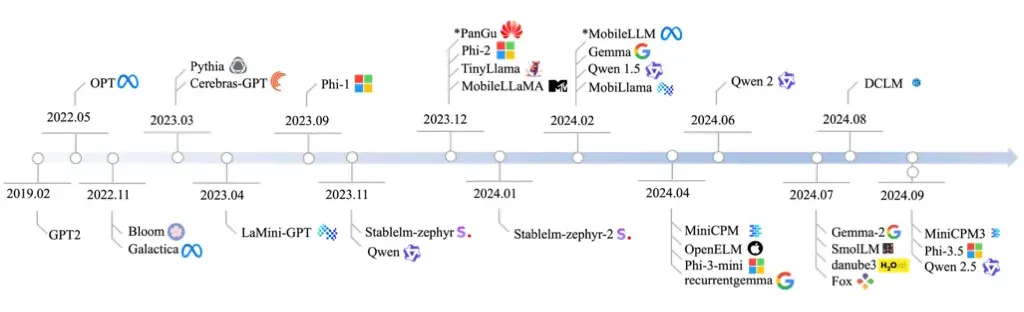

(3) 장점
1. 효과적인 성능
2. 지연 시간 감소
3. 보안 좋음
4. 접근성, 효율성 좋고 비용 절감 가능

(4) 한계
1. 편향: LLM에 존재하는 편향으로 부터 학습할 수 있음
2. 제한된 일반화: LLM에 비해 광범위한 지식 기반이 부족함.
3. 환각

(5) 결합추론; LLM과 ssM의 결합
* 복잡하고 어려운 작업 -> LLM / 가벼운 작업 ->sLM
* 정확도 달성과 토큰 절약 동시에 잡기 가능